In [3]:
import pandas as pd
df = pd.read_excel("yeni_veri.xlsx", sheet_name="Siparis_Verisi")
print(df.shape)
df.head()

(7589, 18)


,order_id,parent_order_id,material_id,material_type,supplier_type,product_tree_level,order_quantity,order_month,requested_lead_time_days,procurement_lead_time_days,step_A_hours,step_B_hours,step_C_hours,step_D_hours,production_time_days,total_lead_time_days,delay_days,is_delayed
0,1,NaN,P_1,final_product,domestic,0,41,3,5.59,0,0.000,0.000,0.000,0.000,5.99,5.99,0.40,1
1,2,1.0,M38,purchased,domestic,1,82,3,55.00,53,0.000,0.000,0.000,0.000,0.00,53.00,0.00,0
2,3,1.0,M178,in_house,domestic,1,82,3,6.16,0,18.813,15.708,12.739,6.419,6.71,6.71,0.55,1
3,4,3.0,M142,purchased,foreign,2,164,3,50.00,13,0.000,0.000,0.000,0.000,0.00,13.00,0.00,0
4,5,3.0,M61,purchased,foreign,2,246,3,50.00,50,0.000,0.000,0.000,0.000,0.00,50.00,0.00,0


In [4]:
print(df.info())
print(df.describe())
print("--- eksik değerler ---")
print(df.isnull().sum())
print("--- tekrarlanan satırlar ---")
print(df.duplicated().sum())
print("--- benzersiz değer sayıları ---")
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 7589 entries, 0 to 7588
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    7589 non-null   int64  
 1   parent_order_id             7489 non-null   float64
 2   material_id                 7589 non-null   str    
 3   material_type               7589 non-null   str    
 4   supplier_type               7589 non-null   str    
 5   product_tree_level          7589 non-null   int64  
 6   order_quantity              7589 non-null   int64  
 7   order_month                 7589 non-null   int64  
 8   requested_lead_time_days    7589 non-null   float64
 9   procurement_lead_time_days  7589 non-null   int64  
 10  step_A_hours                7589 non-null   float64
 11  step_B_hours                7589 non-null   float64
 12  step_C_hours                7589 non-null   float64
 13  step_D_hours                7589 non-null   

In [5]:
print(df["material_type"].value_counts())
print(df["supplier_type"].value_counts())

material_type
purchased        5969
subcontracted     906
in_house          614
final_product     100
Name: count, dtype: int64
supplier_type
foreign     3926
domestic    3663
Name: count, dtype: int64


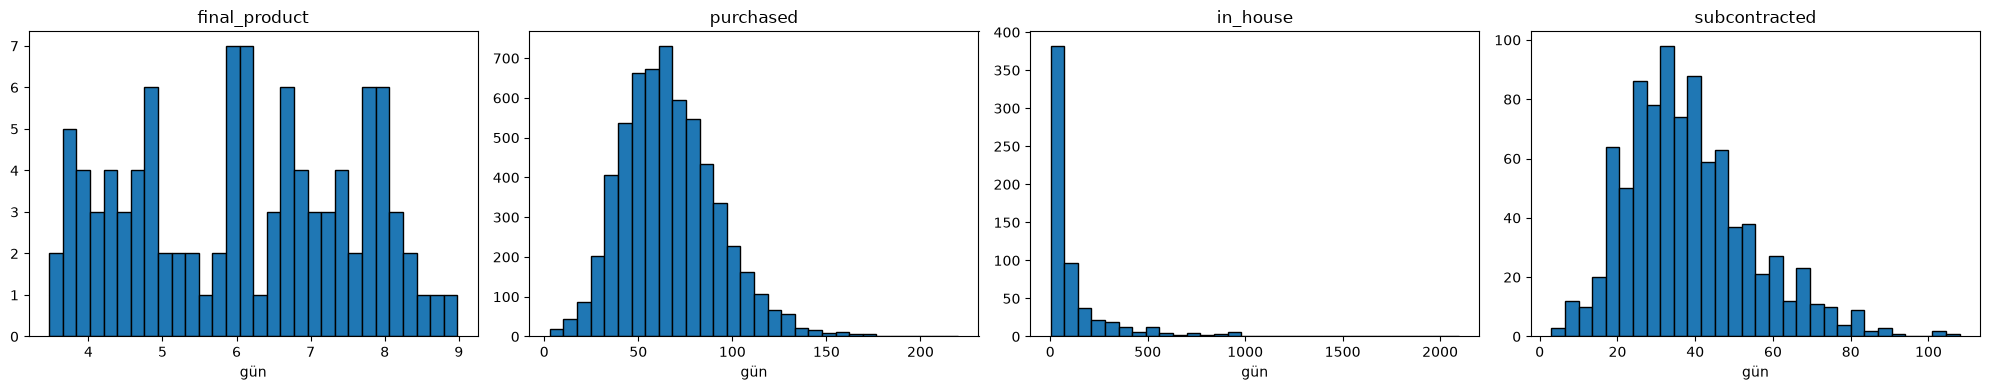

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, t in zip(axes, df["material_type"].unique()):
    subset = df[df["material_type"] == t]["total_lead_time_days"]
    ax.hist(subset, bins=30, edgecolor="black")
    ax.set_title(t)
    ax.set_xlabel("gün")
plt.tight_layout()
plt.show()

In [7]:
print(df.groupby("material_type")["total_lead_time_days"].agg(["mean","median","min","max"]).round(1))

                mean  median  min     max
material_type                            
final_product    6.1     6.2  3.5     9.0
in_house       120.6    39.2  2.0  2096.1
purchased       66.8    65.0  3.0   220.0
subcontracted   38.1    36.0  3.0   108.0


<Figure size 800x600 with 0 Axes>

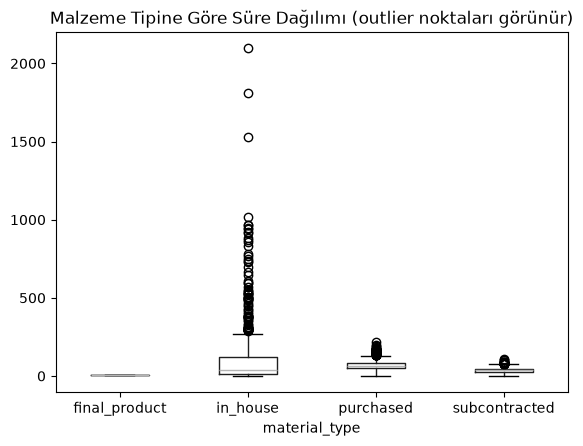

<Figure size 800x600 with 0 Axes>

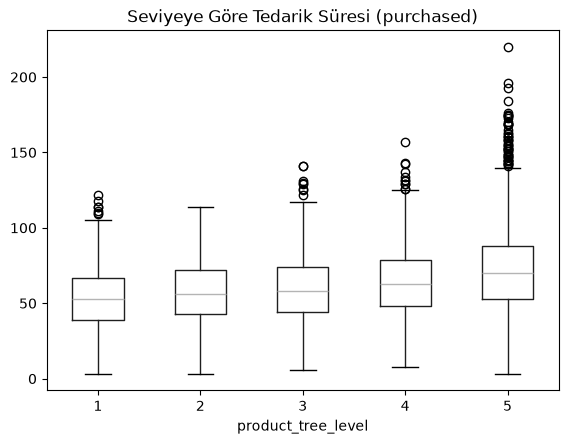

In [8]:
plt.figure(figsize=(8,6))
df.boxplot(column="total_lead_time_days", by="material_type", grid=False)
plt.suptitle("")
plt.title("Malzeme Tipine Göre Süre Dağılımı (outlier noktaları görünür)")
plt.show()

purchased_only = df[df["material_type"] == "purchased"]
plt.figure(figsize=(8,6))
purchased_only.boxplot(column="total_lead_time_days", by="product_tree_level", grid=False)
plt.suptitle("")
plt.title("Seviyeye Göre Tedarik Süresi (purchased)")
plt.show()

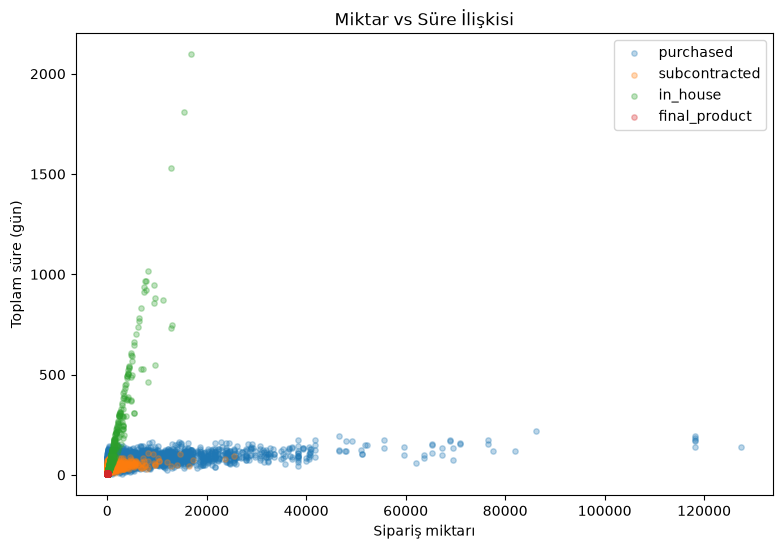

In [9]:
plt.figure(figsize=(9,6))
colors = {"purchased":"tab:blue","subcontracted":"tab:orange","in_house":"tab:green","final_product":"tab:red"}
for t, c in colors.items():
    subset = df[df["material_type"] == t]
    plt.scatter(subset["order_quantity"], subset["total_lead_time_days"], alpha=0.3, s=15, label=t, color=c)
plt.xlabel("Sipariş miktarı"); plt.ylabel("Toplam süre (gün)")
plt.legend(); plt.title("Miktar vs Süre İlişkisi")
plt.show()

In [10]:
def flag_outliers_iqr(group):
    q1, q3 = group.quantile(0.25), group.quantile(0.75)
    iqr = q3 - q1
    return (group < q1 - 1.5*iqr) | (group > q3 + 1.5*iqr)

df["is_outlier"] = df.groupby("material_type")["total_lead_time_days"].transform(flag_outliers_iqr)
print(df.groupby("material_type")["is_outlier"].agg(["sum","mean"]).round(3))
print(f"Toplam outlier: {df.is_outlier.sum()} satır (%{100*df.is_outlier.mean():.1f})")

               sum   mean
material_type            
final_product    0  0.000
in_house        76  0.124
purchased       85  0.014
subcontracted   26  0.029
Toplam outlier: 187 satır (%2.5)


In [11]:
df_clean = df[~df["is_outlier"]].copy()
print(f"Önce: {df.shape[0]} satır -> Sonra: {df_clean.shape[0]} satır")

Önce: 7589 satır -> Sonra: 7402 satır


In [12]:

FEATURES = ["material_id", "material_type", "product_tree_level",
            "supplier_type", "order_quantity", "order_month",
            "requested_lead_time_days"]
TARGET = "total_lead_time_days"

X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()
print(X.shape, y.shape)

(7402, 7) (7402,)


In [13]:
import numpy as np
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[numeric_cols].corr()["total_lead_time_days"].sort_values(ascending=False)
print(corr.round(3))

total_lead_time_days          1.000
requested_lead_time_days      0.743
procurement_lead_time_days    0.701
delay_days                    0.607
step_A_hours                  0.382
step_C_hours                  0.371
product_tree_level            0.362
step_B_hours                  0.359
order_quantity                0.357
step_D_hours                  0.352
is_delayed                    0.348
production_time_days          0.232
order_month                   0.004
parent_order_id              -0.000
order_id                     -0.001
Name: total_lead_time_days, dtype: float64


In [14]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
X_encoded = X.copy()
for col in ["material_id", "material_type", "supplier_type"]:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le
print("material_type kategorileri:", encoders["material_type"].classes_)

material_type kategorileri: ['final_product' 'in_house' 'purchased' 'subcontracted']


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Eğitim:", X_train.shape[0], " Test:", X_test.shape[0])

Eğitim: 5921  Test: 1481


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f} gün | RMSE: {rmse:.2f} gün | MAPE: %{mape:.1f} | R²: {r2:.3f}")

MAE: 11.15 gün | RMSE: 15.10 gün | MAPE: %23.6 | R²: 0.761


In [17]:
test_results = pd.DataFrame({
    "material_type": df_clean.loc[X_test.index, "material_type"].values,
    "gercek": y_test.values, "tahmin": y_pred,
})
test_results["hata"] = (test_results["gercek"] - test_results["tahmin"]).abs()
test_results["mape"] = test_results["hata"] / test_results["gercek"] * 100

print(test_results.groupby("material_type").agg(
    ortalama_sure=("gercek","mean"), MAE=("hata","mean"),
    MAPE=("mape","mean"), adet=("hata","count")
).round(2))

               ortalama_sure    MAE   MAPE  adet
material_type                                   
final_product           6.03   0.37   6.50    25
in_house               63.49   3.18   5.44   117
purchased              65.17  12.86  25.80  1163
subcontracted          36.78   6.75  23.89   176


                    ozellik      onem
6  requested_lead_time_days  0.577230
4            order_quantity  0.208420
0               material_id  0.100515
5               order_month  0.047695
1             material_type  0.039058
2        product_tree_level  0.018818
3             supplier_type  0.008264


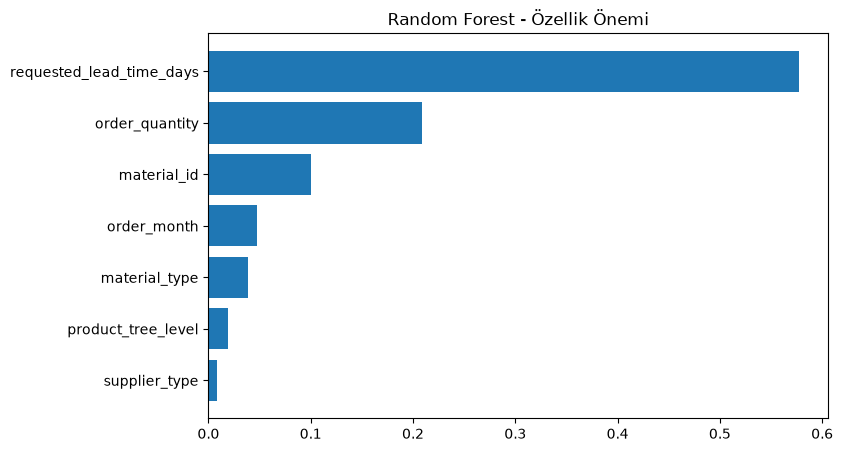

In [18]:
importance_df = pd.DataFrame({
    "ozellik": FEATURES, "onem": model.feature_importances_
}).sort_values("onem", ascending=False)
print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df["ozellik"], importance_df["onem"])
plt.gca().invert_yaxis()
plt.title("Random Forest - Özellik Önemi")
plt.show()

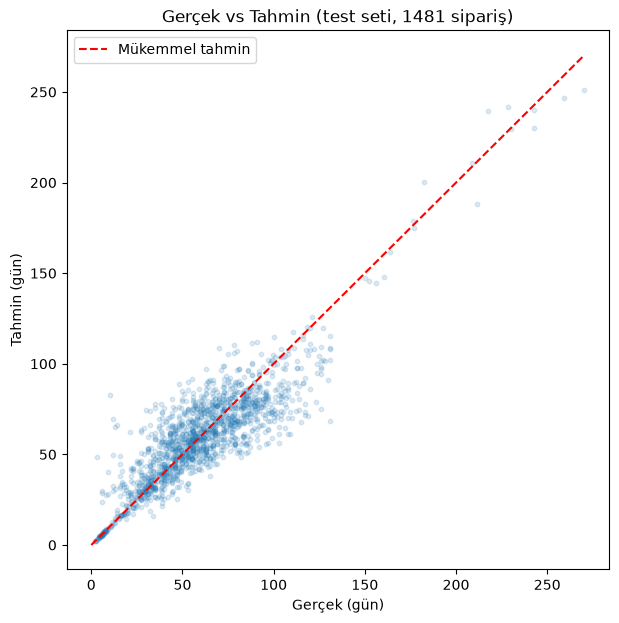

In [19]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.15, s=10)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek (gün)"); plt.ylabel("Tahmin (gün)")
plt.title(f"Gerçek vs Tahmin (test seti, {len(y_test)} sipariş)")
plt.legend(); plt.show()

In [20]:
yeni_siparis = pd.DataFrame({
    "material_id": ["M23"], "material_type": ["purchased"], "product_tree_level": [2],
    "supplier_type": ["foreign"], "order_quantity": [150], "order_month": [7],
    "requested_lead_time_days": [30],
})
yeni_siparis_encoded = yeni_siparis.copy()
for col in ["material_id", "material_type", "supplier_type"]:
    yeni_siparis_encoded[col] = encoders[col].transform(yeni_siparis_encoded[col])

tahmin = model.predict(yeni_siparis_encoded[FEATURES])
print(f"Tahmini toplam süre: {tahmin[0]:.1f} gün")

Tahmini toplam süre: 34.4 gün


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {"min_samples_leaf": [3, 5, 10], "max_depth": [20, None]}
grid = GridSearchCV(
    RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid.fit(X_train, y_train)

print("En iyi parametreler:", grid.best_params_)
print(f"CV MAE: {-grid.best_score_:.2f}")
best_model = grid.best_estimator_
print(f"Final Test MAE: {mean_absolute_error(y_test, best_model.predict(X_test)):.2f}")

En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 5}
CV MAE: 11.74
Final Test MAE: 11.19


In [22]:
def train_and_score(feature_list):
    X = df_clean[feature_list].copy(); y = df_clean["total_lead_time_days"].copy()
    for col in ["material_id", "material_type", "supplier_type"]:
        if col in X.columns:
            X[col] = LabelEncoder().fit_transform(X[col])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return mean_absolute_error(y_test, pred), r2_score(y_test, pred)

mae_full, r2_full = train_and_score(FEATURES)
print(f"TAM MODEL (7 özellik) -> MAE={mae_full:.2f}  R²={r2_full:.3f}")

for f in FEATURES:
    remaining = [x for x in FEATURES if x != f]
    mae, r2 = train_and_score(remaining)
    print(f"{f:28s} ÇIKARILDI -> MAE={mae:6.2f} (fark: {mae-mae_full:+.2f})")

TAM MODEL (7 özellik) -> MAE=11.15  R²=0.761
material_id                  ÇIKARILDI -> MAE= 12.47 (fark: +1.31)
material_type                ÇIKARILDI -> MAE= 11.22 (fark: +0.06)
product_tree_level           ÇIKARILDI -> MAE= 11.15 (fark: -0.01)
supplier_type                ÇIKARILDI -> MAE= 11.14 (fark: -0.01)
order_quantity               ÇIKARILDI -> MAE= 12.90 (fark: +1.74)
order_month                  ÇIKARILDI -> MAE= 11.46 (fark: +0.30)
requested_lead_time_days     ÇIKARILDI -> MAE= 11.72 (fark: +0.57)


In [23]:
def get_product_tree(df, root_order_id):
    ids = {root_order_id}
    frontier = [root_order_id]
    while frontier:
        children = df.loc[df["parent_order_id"].isin(frontier), "order_id"].tolist()
        ids.update(children)
        frontier = children
    return df[df["order_id"].isin(ids)].copy()


def forecast_with_ci(df_full, model, encoders, FEATURES, root_order_id,
                      quantity_multiplier=1.0, new_month=None):
    """
    300 agacin HER BIRINI ayri ayri kritik yoldan gecirip, ortaya cikan
    300 farkli 'senaryo'nun dagilimindan ortalama + guven araligi cikarir.
    Ayni agac indeksi tum dugumlerde tutarli kullanilir (korelasyonu korur).
    """
    tree = get_product_tree(df_full, root_order_id).set_index("order_id")

    children_map = {}
    for oid, row in tree.iterrows():
        p = row["parent_order_id"]
        if pd.notna(p):
            children_map.setdefault(int(p), []).append(oid)

    n_trees = len(model.estimators_)
    predicted_own_all = {}
    for oid, row in tree.iterrows():
        scenario_qty = max(1, int(round(row["order_quantity"] * quantity_multiplier)))
        feat = pd.DataFrame([{
            "material_id": row["material_id"], "material_type": row["material_type"],
            "product_tree_level": row["product_tree_level"], "supplier_type": row["supplier_type"],
            "order_quantity": scenario_qty,
            "order_month": new_month if new_month else row["order_month"],
            "requested_lead_time_days": row["requested_lead_time_days"],
        }])
        for col in ["material_id", "material_type", "supplier_type"]:
            feat[col] = encoders[col].transform(feat[col])
        tree_preds = np.array([est.predict(feat[FEATURES].values)[0] for est in model.estimators_])
        predicted_own_all[oid] = tree_preds

    memo = {}
    def completion(oid, s):
        key = (oid, s)
        if key in memo:
            return memo[key]
        kids = children_map.get(oid, [])
        own = predicted_own_all[oid][s]
        result = own if not kids else own + max(completion(k, s) for k in kids)
        memo[key] = result
        return result

    return np.array([completion(root_order_id, i) for i in range(n_trees)])

In [24]:
root_id = df[df["parent_order_id"].isna()]["order_id"].iloc[0]
urun_adi = df[df["order_id"] == root_id]["material_id"].values[0]

print(f"ÜRÜN: {urun_adi}  —  KARAR DESTEK TABLOSU")
print("=" * 80)

sonuclar = []
for mult in [0.5, 1.0, 1.5, 2.0]:
    res = forecast_with_ci(df, model, encoders, FEATURES, root_id, quantity_multiplier=mult)
    sonuclar.append({
        "miktar_carpani": f"x{mult}",
        "ortalama_gun": round(res.mean(), 1),
        "std": round(res.std(), 1),
        "p5_iyimser": round(np.percentile(res, 5), 1),
        "p50_medyan": round(np.percentile(res, 50), 1),
        "p95_kotumser": round(np.percentile(res, 95), 1),
    })

pd.DataFrame(sonuclar)

ÜRÜN: P_1  —  KARAR DESTEK TABLOSU


,miktar_carpani,ortalama_gun,std,p5_iyimser,p50_medyan,p95_kotumser
0,x0.5,526.0,24.4,487.7,527.5,565.7
1,x1.0,555.0,17.9,526.3,556.7,580.2
2,x1.5,550.9,23.2,511.7,551.9,583.5
3,x2.0,560.8,20.2,527.7,561.8,589.0


In [25]:

import ipywidgets as widgets
from IPython.display import display, clear_output

urun_listesi = sorted(df[df["material_type"] == "final_product"]["material_id"].unique())

urun_secim = widgets.Dropdown(options=urun_listesi, description="Ürün:")
miktar_giris = widgets.IntText(value=50, description="Miktar:")
hesapla_buton = widgets.Button(description="Hesapla", button_style="success")
cikti_alani = widgets.Output()

def hesapla_tiklandi(b):
    with cikti_alani:
        clear_output()
        secilen_urun = urun_secim.value
        secilen_miktar = miktar_giris.value

        # Bu urunun orijinal siparis miktarini bul, carpani hesapla
        orijinal_qty = df[df["material_id"] == secilen_urun]["order_quantity"].iloc[0]
        carpan = secilen_miktar / orijinal_qty

        print(f"Hesaplanıyor: {secilen_urun}, {secilen_miktar} adet...")
        sonuc = forecast_with_ci(df, model, encoders, FEATURES,
                                   df[df["material_id"] == secilen_urun]["order_id"].iloc[0],
                                   quantity_multiplier=carpan)

        print()
        print(f"ÜRÜN: {secilen_urun}  |  MİKTAR: {secilen_miktar} adet")
        print("=" * 50)
        print(f"Tahmini süre (ortalama): {sonuc.mean():.0f} gün")
        print(f"%90 güven aralığı: {np.percentile(sonuc,5):.0f} - {np.percentile(sonuc,95):.0f} gün")
        print(f"En olası (medyan): {np.percentile(sonuc,50):.0f} gün")

hesapla_buton.on_click(hesapla_tiklandi)

display(widgets.VBox([
    widgets.HTML("<h3>Tedarik Süresi Tahmin Aracı</h3>"),
    urun_secim, miktar_giris, hesapla_buton, cikti_alani
]))